In [1]:
# ==========================================
# CELL 1: SETUP & IMPORTS
# ==========================================
import os
import glob
import math as mt
import cmath as cmt
import numpy as np
import pickle
import scipy
import scipy.io as sio
from scipy.fftpack import fft, fftshift
from scipy.signal.windows import hann
import osqp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# --- CONFIGURATION (Replaces argparse) ---
class Config:
    dir_data = './doppler_traces/'                    # Updated directory
    subdirs = 'S1a,S1b,S1c'                           # Training/Validation subdirs
    test_subdirs = 'S2a,S2b,S3a,S4a,S4b,S5a,S6a,S6b,S7a' # Explicit Testing subdirs
    name_base = 'csi_experiment' 
    activities = 'E,L,W,R,J'                          # Updated to match your activities flag
    
    feature_length = 100          # Stays 100 (from 100-point FFT in the computation script)
    sample_length = 340           # Windows length from your args
    channels = 1                  
    batch_size = 32               
    num_tot = 4                   # Matches your n_tot argument
    
    bandwidth = 80                
    sub_band = 1                  
    epochs = 25                   
    learning_rate = 0.0001
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cfg = Config()

# Plotting Settings
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 16

In [2]:
# ==========================================
# CELL 2: DATASET UTILITIES
# ==========================================

def expand_antennas(file_names, labels, num_antennas):
    file_names_expanded = [item for item in file_names for _ in range(num_antennas)]
    labels_expanded = [item for item in labels for _ in range(num_antennas)]
    stream_ant = np.tile(np.arange(num_antennas), len(labels))
    return file_names_expanded, labels_expanded, stream_ant

class CSIDataset(Dataset):
    def __init__(self, csi_matrix_files, labels, stream_ant=None):
        self.csi_matrix_files = csi_matrix_files
        self.labels = labels
        self.stream_ant = stream_ant

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        csi_file = self.csi_matrix_files[idx]
        label = self.labels[idx]
        stream_a = self.stream_ant[idx]

        if isinstance(csi_file, (bytes, bytearray)):
            csi_file = csi_file.decode()

        with open(csi_file, "rb") as fp:
            matrix_csi = pickle.load(fp)

        # Extract single stream and format for PyTorch (Channels, Height, Width)
        matrix_csi_single = matrix_csi[stream_a, ...].T
        if len(matrix_csi_single.shape) < 3:
            # Expand on channel dimension (axis=0 for PyTorch)
            matrix_csi_single = np.expand_dims(matrix_csi_single, axis=0)
        else:
            # Permute to (C, H, W) if it already has channels
            matrix_csi_single = np.transpose(matrix_csi_single, (2, 0, 1))

        tensor_csi = torch.tensor(matrix_csi_single, dtype=torch.float32)
        tensor_label = torch.tensor(label, dtype=torch.long)

        return tensor_csi, tensor_label

def get_dataloader(files, labels, stream_ant, batch_size, shuffle=True):
    dataset = CSIDataset(files, labels, stream_ant)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

In [3]:
# ==========================================
# CELL 3: NETWORK UTILITIES
# ==========================================

class Conv2dBN(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, activation='relu', bn=False):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_channels) if bn else nn.Identity()
        self.activation = nn.ReLU() if activation == 'relu' else nn.Identity()

    def forward(self, x):
        return self.activation(self.bn(self.conv(x)))

class SamePadConv2d(nn.Module):
    """Custom wrapper to mimic TensorFlow's padding='same' behavior for stride > 1"""
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride)
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x):
        in_h, in_w = x.size(2), x.size(3)
        out_h = mt.ceil(in_h / self.stride)
        out_w = mt.ceil(in_w / self.stride)
        pad_h = max((out_h - 1) * self.stride + self.kernel_size - in_h, 0)
        pad_w = max((out_w - 1) * self.stride + self.kernel_size - in_w, 0)
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, [pad_w//2, pad_w - pad_w//2, pad_h//2, pad_h - pad_h//2])
        return self.conv(x)

class ReductionABlockSmall(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = Conv2dBN(in_channels, 5, kernel_size=2, stride=2, bn=True)
        
        self.conv3_1 = Conv2dBN(in_channels, 3, kernel_size=1, bn=True)
        self.conv3_2 = Conv2dBN(3, 6, kernel_size=2, bn=True)
        # Emulating TF padding='same' for stride=2
        self.conv3_3_pad = SamePadConv2d(6, 9, kernel_size=4, stride=2)
        self.conv3_3_bn = nn.BatchNorm2d(9)
        self.conv3_3_act = nn.ReLU()

    def forward(self, x):
        x1 = self.pool1(x)
        x2 = self.conv2(x)
        
        x3 = self.conv3_1(x)
        x3 = self.conv3_2(x)
        x3 = self.conv3_3_act(self.conv3_3_bn(self.conv3_3_pad(x3)))
        
        # Ensure dimensions match before concatenation (due to edge case sizing)
        min_h = min(x1.size(2), x2.size(2), x3.size(2))
        min_w = min(x1.size(3), x2.size(3), x3.size(3))
        
        x1 = x1[:, :, :min_h, :min_w]
        x2 = x2[:, :, :min_h, :min_w]
        x3 = x3[:, :, :min_h, :min_w]
        
        return torch.cat([x1, x2, x3], dim=1)

class CSINetwork(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.reduction = ReductionABlockSmall(in_channels)
        
        # in_channels + 5 + 9
        red_out_channels = in_channels + 14 
        self.conv4 = Conv2dBN(red_out_channels, 3, kernel_size=1, bn=True)
        
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.LazyLinear(num_classes)

    def forward(self, x):
        x = self.reduction(x)
        x = self.conv4(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [5]:
# ==========================================
# CELL 4: DATA PREPARATION (FINAL)
# ==========================================
activities = np.asarray(cfg.activities.split(','))
labels_considered = np.arange(len(activities))

# Added a `subdirs_str` argument so we can specify where to look
def load_split(split_name, subdirs_str):
    labels, all_files = [],[]
    for sdir in subdirs_str.split(','):
        # Path constructor
        name_labels = f"{cfg.dir_data}{sdir}/labels_{split_name}_antennas_{cfg.activities}.txt"
        name_f = f"{cfg.dir_data}{sdir}/files_{split_name}_antennas_{cfg.activities}.txt"
        
        if os.path.exists(name_labels):
            with open(name_labels, "rb") as fp:
                labels.extend(pickle.load(fp))
        else:
            print(f"⚠️ Could not find labels for {split_name} in {sdir} at {name_labels}")
            
        if os.path.exists(name_f):
            with open(name_f, "rb") as fp:
                all_files.extend(pickle.load(fp))
        else:
            print(f"⚠️ Could not find files for {split_name} in {sdir} at {name_f}")
                
    # Filter out labels not being considered
    files_sel = [all_files[i] for i in range(len(labels)) if labels[i] in labels_considered]
    labels_sel = [labels[i] for i in range(len(labels)) if labels[i] in labels_considered]
    
    # Expand for multiple antennas
    f_exp, l_exp, s_exp = expand_antennas(files_sel, labels_sel, cfg.num_tot)
    return files_sel, labels_sel, f_exp, l_exp, s_exp

# Load Splits
# Fetch Train/Val from S1a,S1b,S1c
_, _, f_train, l_train, s_train = load_split('train', cfg.subdirs)
_, _, f_val, l_val, s_val = load_split('val', cfg.subdirs)

# Fetch Test from S2a...S7a. Note we use 'complete' because the test dataset creator script outputs 'complete_antennas_...'
files_test, labels_test, f_test, l_test, s_test = load_split('complete', cfg.test_subdirs)

# Initialize Dataloaders
train_loader = get_dataloader(f_train, l_train, s_train, cfg.batch_size, shuffle=True)
val_loader = get_dataloader(f_val, l_val, s_val, cfg.batch_size, shuffle=False)
test_loader = get_dataloader(f_test, l_test, s_test, cfg.batch_size, shuffle=False)

print(f"Train samples: {len(f_train)} | Val samples: {len(f_val)} | Test samples: {len(f_test)}")

Train samples: 21648 | Val samples: 6692 | Test samples: 119400


In [6]:
# ==========================================
# CELL 5: TRAINING LOOP
# ==========================================
model = CSINetwork(in_channels=cfg.channels, num_classes=len(activities)).to(cfg.device)

# Dummy pass to initialize LazyLinear weights
_dummy = torch.zeros(1, cfg.channels, cfg.sample_length, cfg.feature_length).to(cfg.device)
model(_dummy)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate)

best_val_acc = 0.0
patience, patience_counter = 3, 0
best_model_path = f"{cfg.name_base}_{cfg.activities}_network.pth"

for epoch in range(cfg.epochs):
    # --- TRAINING ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(cfg.device), targets.to(cfg.device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += targets.size(0)
        train_correct += (predicted == targets).sum().item()
        
    train_acc = train_correct / train_total
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(cfg.device), targets.to(cfg.device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += targets.size(0)
            val_correct += (predicted == targets).sum().item()
            
    val_acc = val_correct / val_total
    print(f"Epoch [{epoch+1}/{cfg.epochs}] Train Loss: {train_loss/len(train_loader):.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss/len(val_loader):.4f} Acc: {val_acc:.4f}")
    
    # Early Stopping & Checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/25] Train Loss: 0.4570 Acc: 0.8147 | Val Loss: 0.4106 Acc: 0.8319
Epoch [2/25] Train Loss: 0.1608 Acc: 0.9448 | Val Loss: 0.1525 Acc: 0.9474
Epoch [3/25] Train Loss: 0.0939 Acc: 0.9702 | Val Loss: 0.0968 Acc: 0.9673
Epoch [4/25] Train Loss: 0.0622 Acc: 0.9812 | Val Loss: 0.1676 Acc: 0.9458
Epoch [5/25] Train Loss: 0.0457 Acc: 0.9873 | Val Loss: 0.1726 Acc: 0.9371
Epoch [6/25] Train Loss: 0.0378 Acc: 0.9889 | Val Loss: 0.9823 Acc: 0.7391
Early stopping triggered.


In [7]:
# ==========================================
# CELL 6: TESTING & METRICS
# ==========================================
# Load best model
model.load_state_dict(torch.load(best_model_path))
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(cfg.device), targets.to(cfg.device)
        outputs = model(inputs)
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

test_prediction_list = np.concatenate(all_preds, axis=0)
test_labels_true = np.concatenate(all_targets, axis=0)
test_labels_pred = np.argmax(test_prediction_list, axis=1)

# Single Antenna Metrics
conf_matrix = confusion_matrix(test_labels_true, test_labels_pred)
precision, recall, fscore, _ = precision_recall_fscore_support(test_labels_true, test_labels_pred, labels=labels_considered)
accuracy = accuracy_score(test_labels_true, test_labels_pred)

# Max-Merge Antenna Metrics
labels_true_merge = np.array(labels_test)
pred_max_merge = np.zeros_like(labels_test)

for i_lab in range(len(labels_test)):
    start_idx = i_lab * cfg.num_tot
    end_idx = (i_lab + 1) * cfg.num_tot
    
    # Merge soft predictions
    pred_antennas = test_prediction_list[start_idx:end_idx, :]
    lab_merge_max = np.argmax(np.sum(pred_antennas, axis=0))
    
    # Handle hard voting ties
    pred_max_antennas = test_labels_pred[start_idx:end_idx]
    lab_unique, count = np.unique(pred_max_antennas, return_counts=True)
    
    if lab_unique.shape[0] > 1:
        count_argsort = np.flip(np.argsort(count))
        count_sort = count[count_argsort]
        lab_unique_sort = lab_unique[count_argsort]
        if count_sort[0] == count_sort[1] or lab_unique.shape[0] > 2:
            lab_max_merge = lab_merge_max
        else:
            lab_max_merge = lab_unique_sort[0]
    else:
        lab_max_merge = lab_unique[0]
        
    pred_max_merge[i_lab] = lab_max_merge

conf_matrix_max_merge = confusion_matrix(labels_true_merge, pred_max_merge, labels=labels_considered)
precision_max_merge, recall_max_merge, fscore_max_merge, _ = precision_recall_fscore_support(labels_true_merge, pred_max_merge, labels=labels_considered)
accuracy_max_merge = accuracy_score(labels_true_merge, pred_max_merge)

print('\n-- FINAL DECISION (MAX MERGE) --')
print(f'Accuracy: {accuracy_max_merge:.4f} | Avg Precision: {np.mean(precision_max_merge):.4f} | Avg F-Score: {np.mean(fscore_max_merge):.4f}')
print(f'F-Scores by class: {fscore_max_merge}')


-- FINAL DECISION (MAX MERGE) --
Accuracy: 0.9178 | Avg Precision: 0.9275 | Avg F-Score: 0.9096
F-Scores by class: [0.99962414 0.99972655 0.79035999 0.84099472 0.9172687 ]


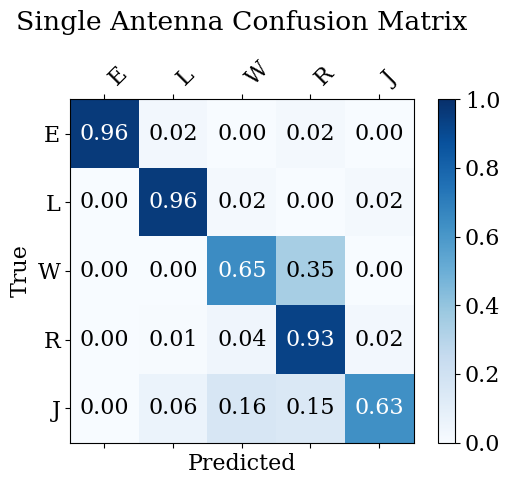

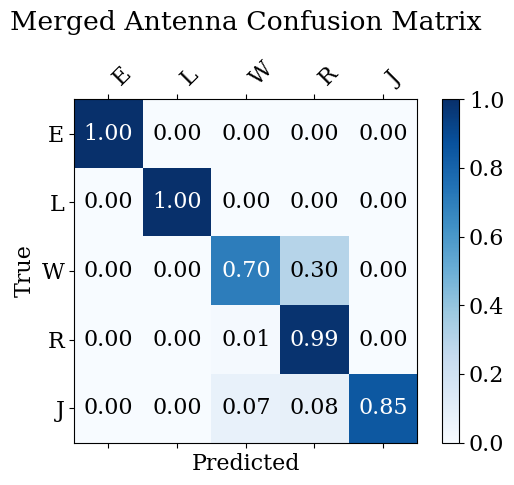

In [8]:
# ==========================================
# CELL 7: PLOTTING
# ==========================================
os.makedirs('./plots/', exist_ok=True)

def plot_cm(cm, classes, title='Confusion matrix'):
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, ax = plt.subplots(figsize=(6, 5))
    cax = ax.matshow(cm_normalized, cmap=plt.cm.Blues, vmin=0, vmax=1)
    fig.colorbar(cax)
    
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="left")
    ax.set_yticklabels(classes)
    
    for i in range(len(classes)):
        for j in range(len(classes)):
            val = cm_normalized[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, format(val, '.2f'), ha="center", va="center", color=color)

    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title, pad=20)
    plt.tight_layout()
    plt.show()

# Visualize
plot_cm(conf_matrix, activities, title="Single Antenna Confusion Matrix")
plot_cm(conf_matrix_max_merge, activities, title="Merged Antenna Confusion Matrix")